In [ ]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, accuracy_score, recall_score, f1_score
)

In [ ]:
# Import the lending club dataset with a cursory examination
REPO_ROOT = Path(__file__).resolve().parent.parent    
LOANS_CSV = REPO_ROOT / "Datasets" / "LC_loans.csv"
OUT = Path(__file__).resolve().parent

df = pd.read_csv(LOANS_CSV)
df.head()

/tmp/ipykernel_4442/2010958992.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/dgc/Documents/Projects/Credit Scorecard/LC_loans.csv')


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  object 
 2   revenue           1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   fico_n            1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  object 
 8   purpose           1347681 non-null  object 
 9   home_ownership_n  1347681 non-null  object 
 10  addr_state        1347681 non-null  object 
 11  zip_code          1347680 non-null  object 
 12  Default           1347681 non-null  int64  
 13  title             1331024 non-null  object 
 14  desc              119099 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 

In [103]:
df.describe()

,id,revenue,dti_n,loan_amnt,fico_n,experience_c,Default
count,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06,1.347681e+06
mean,5.621359e+07,7.736968e+04,1.829909e+01,1.440823e+04,6.981589e+02,9.999814e-01,1.997869e-01
std,3.839501e+07,7.036299e+04,1.115214e+01,8.715347e+03,3.184872e+01,4.306977e-03,3.998402e-01
min,5.473400e+04,1.896000e+03,0.000000e+00,5.000000e+02,6.120000e+02,0.000000e+00,0.000000e+00
25%,1.970651e+07,4.660000e+04,1.182000e+01,7.975000e+03,6.720000e+02,1.000000e+00,0.000000e+00
50%,5.766422e+07,6.500000e+04,1.763000e+01,1.200000e+04,6.920000e+02,1.000000e+00,0.000000e+00
75%,8.449505e+07,9.200000e+04,2.407000e+01,2.000000e+04,7.120000e+02,1.000000e+00,0.000000e+00
max,1.456364e+08,1.099920e+07,9.990000e+02,4.000000e+04,8.475000e+02,1.000000e+00,1.000000e+00


In [105]:
# Split data into training and testing data
ind_vars = ['issue_d', 'revenue', 'dti_n', 'loan_amnt', 'fico_n', 'purpose', 'home_ownership_n', 'emp_length', 'experience_c', 'addr_state', 'title']
dep_var = ['Default']
X_train, X_test, y_train, y_test = train_test_split(df[ind_vars], df[dep_var], test_size=0.2, random_state=42)
Xy_train = X_train.join(y_train)
Xy_test = X_test.join(y_test)

In [106]:
# Function to compute IV for continuous variables, given a number of bins
def get_iv_conts(df: pd.DataFrame, column: str, num_bins: int) -> float:

  total = df.shape[0]

  # Calculate WoE for each bin and IV for the chosen column
  pct_bad_list = []
  pct_good_list = []
  woe_list = []

  for i in range(num_bins):

      # Set upper and lower_bounds for bin
      lower_bound = df[column].quantile(i/num_bins)
      upper_bound = df[column].quantile((i+1)/num_bins)

      # Filter values in range
      filter = (df[column] <= upper_bound) & (df[column] > lower_bound)
      filtered_df = df[filter]

      # Count number of bads and goods for WoE calculation
      num_bads = filtered_df[filtered_df['Default'] == 1].shape[0]
      num_goods = filtered_df[filtered_df['Default'] == 0].shape[0]
      pct_bad = num_bads / total
      pct_bad_list.append(pct_bad)
      pct_good = num_goods / total
      pct_good_list.append(pct_good)

      # Calculate WoE for this bin, taking into account if pct_bad or pct_good is zero
      if pct_good == 0 or pct_bad == 0:
          raise ValueError('pct_good = 0 or pct_bad = 0 in a bin')
          return
      else:
          woe = np.log(pct_good/pct_bad)
          woe_list.append(woe)

  # Calculate IV for this variable
  iv = np.sum((np.array(pct_good_list) - np.array(pct_bad_list)) * np.array(woe_list))

  return iv

In [107]:
# Function to compute IV for discrete variables
def get_iv_disc(df: pd.DataFrame, column: str) -> float:

  total = df.shape[0]
  categories = df[column].unique()
  num_categories = len(categories)

  # Calculate WoE for each bin and IV for the chosen column
  pct_bad_list = []
  pct_good_list = []
  woe_list = []

  for category in categories:

      # Filter values in category
      filter = (df[column] == category)
      filtered_df = df[filter]

      # Count number of bads and goods for WoE calculation
      num_bads = filtered_df[filtered_df['Default'] == 1].shape[0]
      num_goods = filtered_df[filtered_df['Default'] == 0].shape[0]
      pct_bad = num_bads / total
      pct_bad_list.append(pct_bad)
      pct_good = num_goods / total
      pct_good_list.append(pct_good)

      # Calculate WoE for this bin, taking into account if pct_bad or pct_good is zero
      if pct_good == 0 or pct_bad == 0:
          raise ValueError('pct_good = 0 or pct_bad = 0 in a bin')
          return
      else:
          woe = np.log(pct_good/pct_bad)
          woe_list.append(woe)

  # Calculate IV for this variable
  iv = np.sum((np.array(pct_good_list) - np.array(pct_bad_list)) * np.array(woe_list))

  return iv

In [108]:
# Set columns for binning
total = Xy_train.shape[0]
conts_columns = ['revenue', 'dti_n', 'loan_amnt', 'fico_n']
disc_columns = ['issue_d', 'purpose', 'emp_length', 'experience_c', 'addr_state', 'home_ownership_n', 'title']

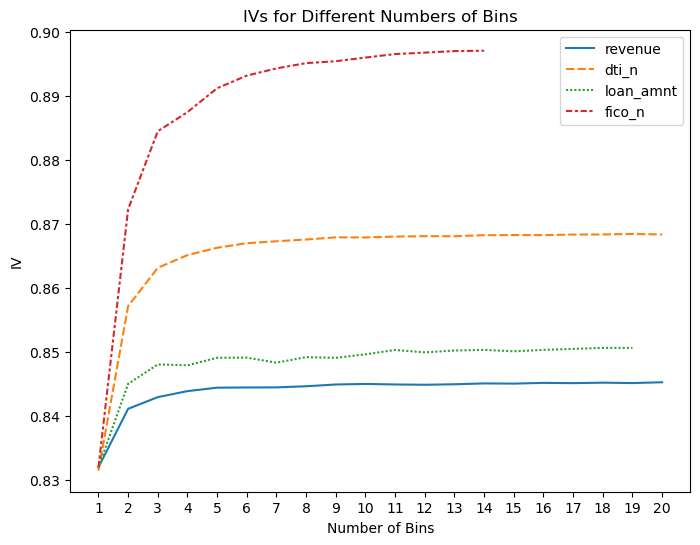

In [109]:
# Plotting graphs of IV against total number of bins for each continuous variable
max_bins = 20
num_bins_range = range(0, max_bins)
conts_iv_df = pd.DataFrame(index = num_bins_range, columns = conts_columns)

# Using the get_iv_conts function to obtain IVs for different total numbers of bins
for column in conts_columns:

  for num_bins in range(1, max_bins+1):

    try:
      iv = get_iv_conts(Xy_train, column, num_bins)
    except ValueError:
      continue
    conts_iv_df.loc[num_bins, column] = iv

# Setting plot features
plt.figure(figsize=(8, 6))
conts_ivs_plot = sns.lineplot(data=conts_iv_df)

plt.title('IVs for Different Numbers of Bins')
plt.xlabel('Number of Bins')
plt.ylabel('IV')
plt.xticks(range(1, max_bins + 1))
plt.legend()
plt.show()

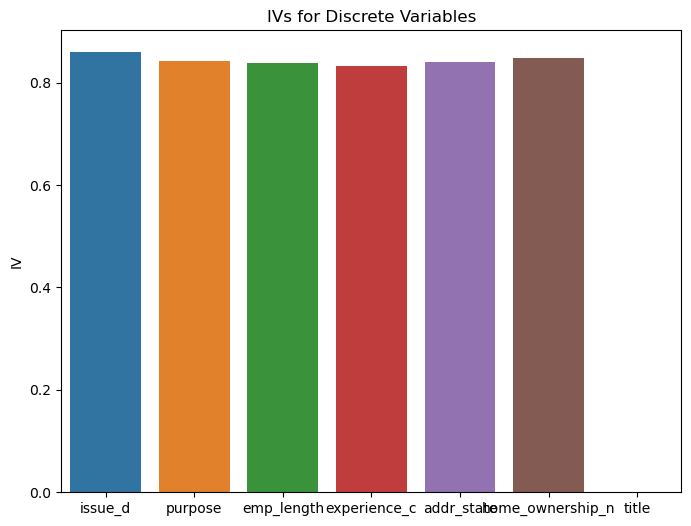

In [110]:
# Plotting graphs of IV against total number of bins for each discrete variable
disc_iv_df = pd.DataFrame(columns = disc_columns)

# Using the get_iv_disc function to obtain IVs
for column in disc_columns:

  try:
    iv = get_iv_disc(Xy_train, column)
  except ValueError:
    continue
  disc_iv_df.loc[0, column] = iv

# Setting plot features
plt.figure(figsize=(8, 6))
revenue_ivs_plot = sns.barplot(data=disc_iv_df)

plt.title('IVs for Discrete Variables')
plt.ylabel('IV')
plt.show()

In [111]:
# Drop title from the independent variables
X_train.drop(['title'], axis=1, inplace=True)
X_test.drop(['title'], axis=1, inplace=True)
Xy_train.drop(['title'], axis=1, inplace=True)
Xy_test.drop(['title'], axis=1, inplace=True)
disc_columns.remove('title')

In [112]:
# Replace continuous variable values with WoE for each bin
# 14 bins per continuous variable chosen as optimal

# Make copies of Xy_train for replacement with WoE values
Xy_train_woes = Xy_train.copy()
Xy_test_woes = Xy_test.copy()

for column in conts_columns:

  for i in range(14):

      # Set upper and lower_bounds for bin using Xy_train quantiles
      lower_bound = Xy_train_woes[column].quantile(i/14)
      upper_bound = Xy_train_woes[column].quantile((i+1)/14)

      # Create filter for Xy_train and Xy_test
      filter_train = (Xy_train_woes[column] <= upper_bound) & (Xy_train_woes[column] > lower_bound)
      filter_test = (Xy_test_woes[column] <= upper_bound) & (Xy_test_woes[column] > lower_bound)

      # Filter the combined DataFrame to count bads and goods
      filtered_df = Xy_train_woes.loc[filter_train]

      # Count number of bads and goods
      num_bads = filtered_df[filtered_df['Default'] == 1].shape[0]
      num_goods = filtered_df[filtered_df['Default'] == 0].shape[0]
      total = Xy_train_woes.shape[0]

      # Calculate percentages and WoE
      pct_bad = num_bads / total
      pct_good = num_goods / total
      woe = np.log(pct_good / pct_bad)

      # Replace values in Xy_train and Xy_test with WoE
      Xy_train_woes.loc[filter_train, column] = woe
      Xy_test_woes.loc[filter_test, column] = woe

/tmp/ipykernel_4442/483464419.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.73364697662935' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_train_woes.loc[filter_train, column] = woe
/tmp/ipykernel_4442/483464419.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.73364697662935' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_test_woes.loc[filter_test, column] = woe


In [113]:
# Replace discrete variable values with WoE for each bin
for column in disc_columns:

  categories = Xy_train_woes[column].unique()
  num_categories = len(categories)

  for category in categories:

      # Filter values in category
      filter_train = (Xy_train_woes[column] == category)
      filter_test = (Xy_test_woes[column] == category)

      # Filter the combined DataFrame to count bads and goods
      filtered_df = Xy_train_woes[filter_train]

      # Count number of bads and goods for WoE calculation
      num_bads = filtered_df[filtered_df['Default'] == 1].shape[0]
      num_goods = filtered_df[filtered_df['Default'] == 0].shape[0]
      total = Xy_train_woes.shape[0]
      pct_bad = num_bads / total
      pct_good = num_goods / total

      # Calculate WoE and replace values in each bin with WoE for train and test sets
      woe = np.log(pct_good/pct_bad)
      Xy_train_woes.loc[filter_train, column] = woe
      Xy_test_woes.loc[filter_test, column] = woe

/tmp/ipykernel_4442/2891174988.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.386508867677367' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_train_woes.loc[filter_train, column] = woe
/tmp/ipykernel_4442/2891174988.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.386508867677367' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xy_test_woes.loc[filter_test, column] = woe


In [ ]:
# Split X and y values from Xy_train and Xy_test
X_train_woes = Xy_train_woes.drop(['Default'], axis=1)
y_train_woes = Xy_train_woes['Default']
X_test_woes = Xy_test_woes.drop(['Default'], axis=1)
y_test_woes = Xy_test_woes['Default']

# Write X_train, X_test, y_train and y_test to csv files as a checkpoint
X_train.to_csv(f'{OUT}/X_train.csv', index=False)
X_train_woes.to_csv(f'{OUT}/X_train_woes.csv', index=False)
X_test.to_csv(f'{OUT}/X_test.csv', index=False)
X_test_woes.to_csv(f'{OUT}/X_test_woes.csv', index=False)
y_train.to_csv(f'{OUT}/y_train.csv', index=False)
y_train_woes.to_csv(f'{OUT}/y_train_woes.csv', index=False)
y_test.to_csv(f'{OUT}/y_test.csv', index=False)
y_test_woes.to_csv(f'{OUT}/y_test_woes.csv', index=False)

In [ ]:
# Paths for reading X_train, X_test, y_train and y_test
X_TRAIN = REPO_ROOT / "Datasets" / "X_train.csv"
X_TRAIN_WOES = REPO_ROOT / "Datasets" / "X_train_woes.csv"
X_TEST = REPO_ROOT / "Datasets" / "X_test.csv"
X_TEST_WOES = REPO_ROOT / "Datasets" / "X_test_woes.csv"
Y_TRAIN = REPO_ROOT / "Datasets" / "y_train.csv"
Y_TRAIN_WOES = REPO_ROOT / "Datasets" / "y_train_woes.csv"
Y_TEST = REPO_ROOT / "Datasets" / "y_test.csv"
Y_TEST_WOES = REPO_ROOT / "Datasets" / "y_test_woes.csv"

# Read X_train, X_test, y_train and y_test from paths
X_train = pd.read_csv(X_TRAIN)
X_train_woes = pd.read_csv(X_TRAIN_WOES)
X_test = pd.read_csv(X_TEST)
X_test_woes = pd.read_csv(X_TEST_WOES)
y_train = pd.read_csv(Y_TRAIN)
y_train_woes = pd.read_csv(Y_TRAIN_WOES)
y_test = pd.read_csv(Y_TEST)
y_test_woes = pd.read_csv(Y_TEST_WOES)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


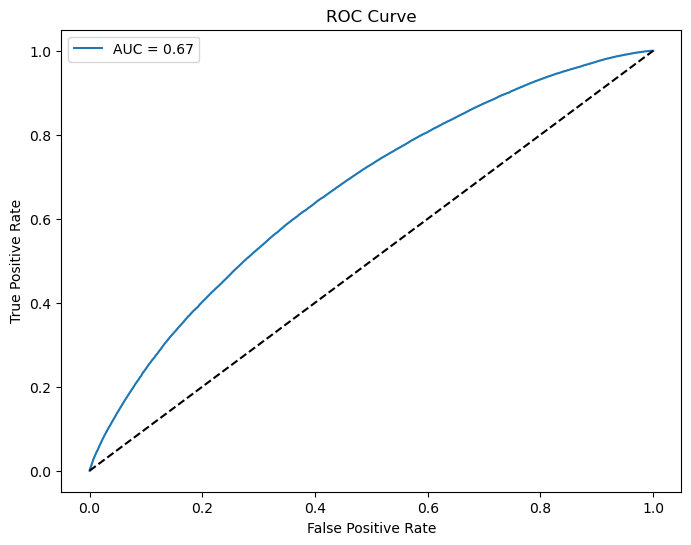

In [116]:
# Fit a Logistic Regression model on the training data
lr_model = LogisticRegression(penalty=None, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_woes, y_train_woes)
y_pred_proba_lr = lr_model.predict_proba(X_test_woes)[:, 1]

# Plot ROC curve with AUC score
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_woes, y_pred_proba_lr)
roc_auc_lr = roc_auc_score(y_test_woes, y_pred_proba_lr)
plt.figure(figsize=(8, 6))
ax_lr = sns.lineplot(x=fpr_lr, y=tpr_lr, label='AUC = %0.2f' % roc_auc_lr)
plt.plot([0, 1], [0, 1], 'k--') # Add a diagonal dashed line for reference
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

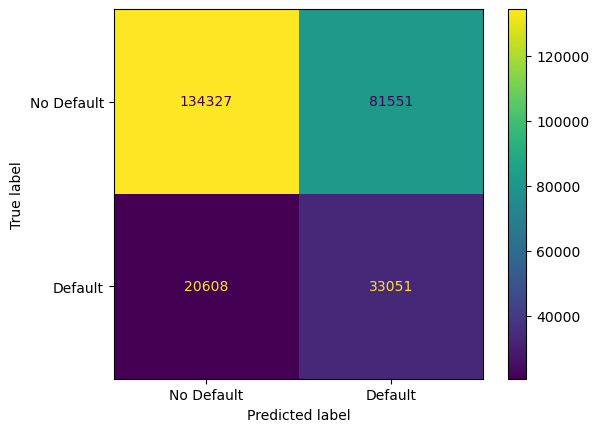

In [117]:
# Determining KS optimal threshold and confusion matrix for the model for this threshold
ks_threshold_lr = np.argmax(tpr_lr - fpr_lr)
y_pred_lr = (y_pred_proba_lr >= thresholds_lr[ks_threshold_lr]).astype(int)
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Default', 'Default'])
disp.plot()

In [118]:
# Computing precision, accuracy, recall and f1 scores
precision_lr = precision_score(y_test_woes, y_pred_lr)
accuracy_lr = accuracy_score(y_test_woes, y_pred_lr)
recall_lr = recall_score(y_test_woes, y_pred_lr)
f1_lr = f1_score(y_test_woes, y_pred_lr)
print(f'Precision: {precision_lr}')
print(f'Accuracy: {accuracy_lr}')
print(f'Recall: {recall_lr}')
print(f'F1 Score: {f1_lr}')

Precision: 0.28839810823545836
Accuracy: 0.6209833900355053
Recall: 0.6159451350192885
F1 Score: 0.39254206679438214


In [119]:
# Examining model parameters
lr_model_coefficients = lr_model.coef_
lr_model_intercept = lr_model.intercept_
lr_model_variables = X_train_woes.columns
model_parameters = pd.DataFrame({'Variable': lr_model_variables, 'Coefficient': lr_model_coefficients[0]})
model_parameters.loc[-1] = {'Variable': 'intercept', 'Coefficient': lr_model_intercept[0]}
model_parameters.index = model_parameters.index + 1
model_parameters = model_parameters.sort_index()
print(model_parameters)

            Variable  Coefficient
0          intercept     4.332472
1            issue_d    -0.919720
2            revenue    -1.168640
3              dti_n    -0.715134
4          loan_amnt    -1.747232
5             fico_n    -0.957284
6            purpose    -0.865371
7   home_ownership_n    -0.827394
8         emp_length    -0.916167
9       experience_c     5.998506
10        addr_state    -1.008568


In [ ]:
# Compute VIFs for the training data. Is there multicollinearity?
X_train_plus = sm.add_constant(X_train_woes.astype(float))

vifs = pd.Series(
    [variance_inflation_factor(X_train_plus.values, i) for i in range(X_train_plus.shape[1])],
    index=X_train_plus.columns
)
print(vifs.drop("const").sort_values(ascending=False))

revenue             1.385133
loan_amnt           1.246741
home_ownership_n    1.090085
dti_n               1.069949
emp_length          1.038858
fico_n              1.026045
issue_d             1.008591
purpose             1.004741
addr_state          1.000580
experience_c        1.000146
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


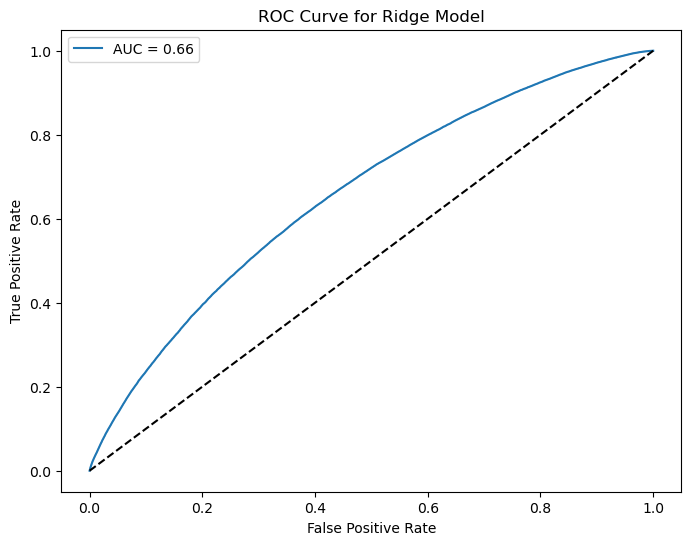

In [ ]:
# Fitting a heavily penalised ridge logistic regression model (fixed C=0.0001).
# Does reducing the effective model complexity reduce overfitting and improve out-of-sample performance?

lr_ridge_model = LogisticRegression(C=0.0001, max_iter=1000, penalty='l2', solver='lbfgs', class_weight='balanced')
lr_ridge_model.fit(X_train_woes, y_train_woes)
y_pred_proba_ridge = lr_ridge_model.predict_proba(X_test_woes)[:, 1]

# Plot ROC curve with AUC score
fpr_ridge, tpr_ridge, thresholds_ridge = roc_curve(y_test_woes, y_pred_proba_ridge)
roc_auc_ridge = roc_auc_score(y_test_woes, y_pred_proba_ridge)
plt.figure(figsize=(8, 6))
ax_ridge = sns.lineplot(x=fpr_ridge, y=tpr_ridge, label='AUC = %0.2f' % roc_auc_ridge)
plt.plot([0, 1], [0, 1], 'k--') # Add a diagonal dashed line for reference
plt.title('ROC Curve for Ridge Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

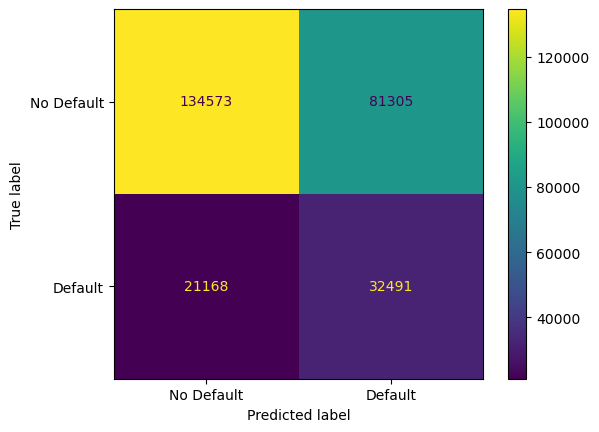

In [123]:
# Determining KS optimal threshold and confusion matrix for the ridge model for this threshold
ks_threshold_ridge = np.argmax(tpr_ridge - fpr_ridge)
y_pred_proba_ridge = (y_pred_proba_ridge >= thresholds_ridge[ks_threshold_ridge]).astype(int)
cm_ridge = confusion_matrix(y_test_woes, y_pred_proba_ridge)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ridge, display_labels=['No Default', 'Default'])
disp.plot()

In [124]:
# Computing precision, accuracy, recall and f1 scores for the ridge model
precision_ridge = precision_score(y_test_woes, y_pred_proba_ridge)
accuracy_ridge = accuracy_score(y_test_woes, y_pred_proba_ridge)
recall_ridge = recall_score(y_test_woes, y_pred_proba_ridge)
f1_ridge = f1_score(y_test_woes, y_pred_proba_ridge)
print(f'Precision: {precision_ridge}')
print(f'Accuracy: {accuracy_ridge}')
print(f'Recall: {recall_ridge}')
print(f'F1 Score: {f1_ridge}')

Precision: 0.28551970192273896
Accuracy: 0.6198184293807529
Recall: 0.6055088615143779
F1 Score: 0.38805649278910753


In [125]:
# Examining model parameters
lr_ridge_model_coefficients = lr_ridge_model.coef_
lr_ridge_model_intercept = lr_ridge_model.intercept_
lr_ridge_model_variables = X_train_woes.columns
model_parameters_ridge = pd.DataFrame({'Variable': lr_ridge_model_variables, 'Coefficient': lr_ridge_model_coefficients[0]})
model_parameters_ridge.loc[-1] = {'Variable': 'intercept', 'Coefficient': lr_ridge_model_intercept[0]}
model_parameters_ridge.index = model_parameters_ridge.index + 1
model_parameters_ridge = model_parameters_ridge.sort_index()
print(model_parameters_ridge)

            Variable  Coefficient
0          intercept     5.527629
1            issue_d    -0.503443
2            revenue    -0.346384
3              dti_n    -0.566270
4          loan_amnt    -0.620617
5             fico_n    -0.723210
6            purpose    -0.304646
7   home_ownership_n    -0.392634
8         emp_length    -0.235541
9       experience_c     0.000559
10        addr_state    -0.293964


In [ ]:
# Comparing accuracy scores (with default threshold of 0.5) from X_train to X_test between the two models
accuracy_lr_ridge_train = lr_ridge_model.score(X_train_woes, y_train_woes)
accuracy_lr_ridge_test = lr_ridge_model.score(X_test_woes, y_test_woes)
accuracy_lr_train = lr_model.score(X_train_woes, y_train_woes)
accuracy_lr_test = lr_model.score(X_test_woes, y_test_woes)

train_test_accuracies = pd.DataFrame({'Model': ['Ridge', 'Unpenalised'], 'Train': [accuracy_lr_ridge_train, accuracy_lr_train], 'Test': [accuracy_lr_ridge_test, accuracy_lr_test]})
train_test_accuracies.set_index('Model', inplace=True)
print(train_test_accuracies)

                Train      Test
Model                          
Ridge        0.589549  0.588494
Unpenalised  0.606046  0.605030


In [127]:
# Creating DataFrames of bin labels and scores to build scorecard for unpenalised model
bin_labels_df = pd.DataFrame(columns=X_train_woes.columns)
bin_scores_df = pd.DataFrame(columns=X_train_woes.columns)

for column in X_train_woes.columns:

    # Quantiles for continuous variables
    if column in conts_columns:

        # Bin labels from quantiles from orginal X_train
        quantiles = [X_train[column].quantile(i/14) for i in range(0, 15)]
        quantile_upper_bounds = [quantiles[i+1] for i in range(0, 14)]
        bin_labels_df[column] = pd.Series(quantile_upper_bounds)

        # Bin scores from WoE and logistic regression model coefficients
        filters = [(X_train[column] <= quantiles[i+1]) & (X_train[column] > quantiles[i]) for i in range(0, 14)]
        index_in_filters = [X_train[filters[i]].index[0] for i in range(0, 14)]
        woes = [X_train_woes.loc[index_in_filters[i], column] for i in range(0, 14)]
        coefficient = model_parameters.loc[model_parameters['Variable'] == column, 'Coefficient'].iloc[0]
        bin_scores_df[column] = pd.Series([coefficient * woes[i] for i in range(0, 14)])

    # Categories for categorical variables
    if column in disc_columns:

        # Bin labels from categories
        categories = df[column].unique()
        bin_labels_df[column] = pd.Series(categories)

        # Bin scores from WoE and logistic regression model coefficients
        filters = [(X_train[column] == category) for category in categories]
        index_in_filters = [X_train[filter].index[0] for filter in filters]
        woes = [X_train_woes.loc[index, column] for index in index_in_filters]
        coefficient = model_parameters.loc[model_parameters['Variable'] == column, 'Coefficient'].iloc[0]
        bin_scores_df[column] = pd.Series([coefficient * woe for woe in woes])

# Write CSV files for scorecard building in Excel
bin_labels_df.to_csv('scorecard_bin_labels.csv')
bin_scores_df.to_csv('scorecard_bin_scores.csv')
        